# Runoff Ratio Analysis — Baseline Long-Term Run

Compare simulated and observed streamflow against forcing precipitation to compute
per-water-year runoff ratios (Q/P) for the East River lumped domain.

**Water year convention:** Oct 1 – Sep 30 (WY YYYY ends Sep 30 YYYY)

In [77]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy.signal import lfilter

## User Inputs

Set `SIM_DIR` to the experiment output directory (e.g. `20260406_bigBuckt`).
All other paths are derived automatically from the standard CONFLUENCE output structure.

In [78]:
# ── Required ──────────────────────────────────────────────────────────────────
SIM_DIR = Path("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260406_bigBuckt_best")

# ── Optional overrides (leave None to use defaults derived from SIM_DIR) ──────
BEST_PARAMS_PATH = None   # default: SIM_DIR / "settings" / "best_parameters.csv"
OBS_PATH         = None   # default: discovered from domain observations directory

# ── Linear reservoir routing toggle ───────────────────────────────────────────
# When True, simulated runoff is routed through two parallel linear reservoirs
# (fast + slow store) at daily timestep, matching the calibration worker logic.
# Parameters are read from best_parameters.csv if present; fallbacks used otherwise.
APPLY_LINEAR_RESERVOIR = False

LR_K_FAST_DEFAULT  = 0.08   # fast-store daily drainage fraction [0–1]
LR_K_SLOW_DEFAULT  = 0.02   # slow-store daily drainage fraction [0–1]
LR_F_FAST_DEFAULT  = 0.70   # fraction of runoff entering fast store [0–1]

# ── Seasonal runoff ratio toggle ───────────────────────────────────────────────
# When True, compute April–July runoff ratio using Oct–Jul precipitation as
# the denominator (captures snowmelt-season efficiency).
CALC_SEASONAL_RR = True

# ── Derived paths (do not edit below unless needed) ───────────────────────────
_domain_root = SIM_DIR.parents[1]   # e.g. .../domain_East_River_lumped

results_nc    = SIM_DIR / "ensemble" / "results" / "baseline_longterm" / "baseline_longterm_timestep.nc"
best_params   = Path(BEST_PARAMS_PATH) if BEST_PARAMS_PATH else SIM_DIR / "settings" / "best_parameters.csv"
attributes_nc = _domain_root / "settings" / "SUMMA" / "attributes.nc"
obs_csv       = Path(OBS_PATH) if OBS_PATH else (
    _domain_root / "observations" / "streamflow" / "preprocessed" /
    f"{_domain_root.name.split('domain_')[1]}_streamflow_processed.csv"
)

# Sanity check
for label, p in [("results_nc", results_nc), ("best_params", best_params),
                 ("attributes_nc", attributes_nc), ("obs_csv", obs_csv)]:
    status = "OK" if p.exists() else "MISSING"
    print(f"[{status}] {label}: {p}")

[OK] results_nc: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260406_bigBuckt_best/ensemble/results/baseline_longterm/baseline_longterm_timestep.nc
[MISSING] best_params: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260406_bigBuckt_best/settings/best_parameters.csv
[OK] attributes_nc: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/attributes.nc
[OK] obs_csv: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv


## Load Data

In [105]:
# ── Simulation ────────────────────────────────────────────────────────────────
ds = xr.open_dataset(results_nc)

# Hourly forcing precipitation [mm/s] → [mm/hr]
ppt_mm_hr = ds["pptrate"].isel(hru=0).to_series() * 3600.0

# Simulated total runoff [m/s] → [mm/hr]
q_sim_mm_hr = ds["scalarTotalRunoff"].isel(hru=0).to_series() * 1000.0 * 3600.0

# Simulated ET [kg m-2 s-1 = mm/s] → [mm/hr]  (scalarTotalET is W/m² in some builds; check units)
et_sim_mm_hr = ds["scalarTotalET"].isel(hru=0).to_series() * 3600.0

# soil storage
soil_storage_mm_hr = (ds['scalarTotalSoilLiq'] + ds['scalarTotalSoilIce'] + ds['scalarAquiferStorage_mean']*1000).isel(hru=0).to_series()

print(f"Simulation period: {ds.time.values[0]}  →  {ds.time.values[-1]}")
print(f"  pptrate units attr : {ds['pptrate'].attrs.get('units', 'not set')} (assumed mm/s)")
print(f"  scalarTotalRunoff  : {ds['scalarTotalRunoff'].attrs.get('units', 'not set')} (assumed m/s)")
print(f"  scalarTotalET      : {ds['scalarTotalET'].attrs.get('units', 'not set')} (assumed mm/s)")
# ── Basin area ────────────────────────────────────────────────────────────────
attrs_ds = xr.open_dataset(attributes_nc)
basin_area_m2 = float(attrs_ds["HRUarea"].values[0])
print(f"\nBasin area: {basin_area_m2/1e6:.1f} km²")

# ── Best parameters ───────────────────────────────────────────────────────────
if not best_params.exists():
    print(f"\n[WARNING] Best parameters file not found at {best_params}. Using defaults.")
else:
    params_df = pd.read_csv(best_params)
    print(f"\nBest parameters loaded from: {best_params}")

    display(params_df)

# ── Observed streamflow ───────────────────────────────────────────────────────
obs_df = pd.read_csv(obs_csv, parse_dates=["datetime"], index_col="datetime")
obs_df.index = obs_df.index.tz_localize(None)
# Convert m³/s → mm/hr
q_obs_mm_hr = obs_df["discharge_cms"] / basin_area_m2 * 1000.0 * 3600.0
q_obs_mm_hr.name = "q_obs_mm_hr"
print(f"\nObservation period: {q_obs_mm_hr.index[0]}  →  {q_obs_mm_hr.index[-1]}")

Simulation period: 1999-10-01T00:00:00.000000000  →  2021-09-30T23:00:00.000013312
  pptrate units attr : kg m-2 s-1 (assumed mm/s)
  scalarTotalRunoff  : m s-1 (assumed m/s)
  scalarTotalET      : kg m-2 s-1 (assumed mm/s)

Basin area: 748.3 km²

[WARNING] Best parameters file not found at /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260406_bigBuckt_best/settings/best_parameters.csv. Using defaults.

Observation period: 1999-10-01 00:00:00  →  2026-04-05 00:00:00


## Linear Reservoir Routing (optional)

Mirrors the two-reservoir daily routing used in `worker_scripts.py` during calibration.
Parameters (`k_fast`, `k_slow`, `f_fast`) are read from `best_parameters.csv` when present;
user-specified defaults apply otherwise. Toggle with `APPLY_LINEAR_RESERVOIR` above.

In [106]:
def _single_reservoir(q_in: np.ndarray, k: float) -> np.ndarray:
    """Linear reservoir routing: q_out = k * storage, storage updated each daily step."""
    q = np.nan_to_num(np.asarray(q_in, dtype=np.float64).ravel(), nan=0.0)
    s = lfilter([1.0], [1.0, -(1.0 - k)], q)
    return np.maximum(k * s, 0.0)


def _two_reservoir(q_daily_mm: pd.Series, k_fast: float, k_slow: float, f_fast: float) -> pd.Series:
    """Route daily runoff through two parallel linear reservoirs."""
    f = float(np.clip(f_fast, 0.0, 1.0))
    q = q_daily_mm.values
    routed = _single_reservoir(f * q, k_fast) + _single_reservoir((1.0 - f) * q, k_slow)
    return pd.Series(routed, index=q_daily_mm.index, name="q_sim_routed_mm_day")


# ── Resolve routing parameters from best_params CSV ───────────────────────────
if APPLY_LINEAR_RESERVOIR:
    _bp = params_df.set_index("parameter")["value"].to_dict() if "parameter" in params_df.columns else {}

    _alias = {"flow_fraction": "f_fast"}   # alternate name used in some calibration runs
    _bp    = {_alias.get(k, k): v for k, v in _bp.items()}

    lr_k_fast = float(_bp.get("k_fast", LR_K_FAST_DEFAULT))
    lr_k_slow = float(_bp.get("k_slow", LR_K_SLOW_DEFAULT))
    lr_f_fast = float(_bp.get("f_fast", LR_F_FAST_DEFAULT))

    # k_slow must be < k_fast (slow reservoir drains more slowly)
    if lr_k_slow >= lr_k_fast:
        lr_k_slow = max(1e-6, lr_k_fast - 1e-6)

    _src_fast  = "best_params" if "k_fast"  in _bp else "default"
    _src_slow  = "best_params" if "k_slow"  in _bp else "default"
    _src_ffast = "best_params" if "f_fast"  in _bp else "default"

    print(f"Linear reservoir routing: {'ENABLED' if APPLY_LINEAR_RESERVOIR else 'disabled'}")
    print(f"  k_fast = {lr_k_fast:.6f}  [{_src_fast}]")
    print(f"  k_slow = {lr_k_slow:.6f}  [{_src_slow}]")
    print(f"  f_fast = {lr_f_fast:.4f}  [{_src_ffast}]")

# ── Resample to daily and optionally apply routing ────────────────────────────
q_sim_mm_day  = q_sim_mm_hr.resample("1D").sum()   # hourly mm/hr → daily mm
ppt_mm_day    = ppt_mm_hr.resample("1D").sum()
et_sim_mm_day = et_sim_mm_hr.resample("1D").sum()
q_obs_mm_day  = q_obs_mm_hr.resample("1D").sum()
delta_storage_mm_day = (soil_storage_mm_hr.shift(1) - soil_storage_mm_hr).resample("1D").sum()

if APPLY_LINEAR_RESERVOIR:
    q_sim_final_mm_day = _two_reservoir(q_sim_mm_day, lr_k_fast, lr_k_slow, lr_f_fast)
    _routing_label = f"sim (routed  k_f={lr_k_fast:.3f}, k_s={lr_k_slow:.3f}, f={lr_f_fast:.2f})"
else:
    q_sim_final_mm_day = q_sim_mm_day.rename("q_sim_mm_day")
    _routing_label = "sim (no routing)"

print(f"\nDaily Q_sim range: {q_sim_final_mm_day.min():.2f} – {q_sim_final_mm_day.max():.2f} mm/day")
print(f"Daily delta_storage range: {delta_storage_mm_day.min():.2f} – {delta_storage_mm_day.max():.2f} mm/day")


Daily Q_sim range: 0.11 – 1210.15 mm/day
Daily delta_storage range: -38.80 – 1100.80 mm/day


## Water-Year Aggregation

Assign each hourly timestep to its water year (Oct 1 → Sep 30), then sum to annual totals.

In [136]:
def water_year(dt_index):
    """Water year (int): Oct 1 of year Y → Sep 30 of year Y+1 is WY Y+1."""
    return dt_index.year + (dt_index.month >= 10).astype(int)


# ── Build daily dataframe ─────────────────────────────────────────────────────
daily = pd.DataFrame({
    "ppt":    ppt_mm_day,
    "q_sim":  q_sim_final_mm_day,
    "et_sim": et_sim_mm_day,
    "q_obs":  q_obs_mm_day.reindex(ppt_mm_day.index),
    "delta_storage": delta_storage_mm_day
})
daily["wy"] = water_year(daily.index)

# ── Annual totals [mm/yr] ─────────────────────────────────────────────────────
wy_totals = daily.groupby("wy")[["ppt", "q_sim", "et_sim", "q_obs", "delta_storage"]].sum()

# Mask obs water years with >20% missing days
obs_coverage = daily.groupby("wy")["q_obs"].apply(lambda x: x.notna().mean())
wy_totals["obs_coverage"] = obs_coverage
wy_totals.loc[obs_coverage < 0.80, "q_obs"] = np.nan

# Drop incomplete boundary water years (<335 days)
days_per_wy = daily.groupby("wy").size()
wy_totals = wy_totals[days_per_wy >= 335].loc[2003:]

# ── Annual runoff ratios ──────────────────────────────────────────────────────
wy_totals["rr_sim"] = wy_totals["q_sim"] / wy_totals["ppt"]
wy_totals["rr_obs"] = wy_totals["q_obs"] / wy_totals["ppt"]


# ── ET and storage anomalies ──────────────────────────────────────────────────────
wy_totals["et_anomaly"] = (wy_totals["et_sim"] - wy_totals["et_sim"].mean()) / wy_totals["et_sim"].std()
wy_totals["storage_anomaly"] = (wy_totals["delta_storage"] - wy_totals["delta_storage"].mean()) / wy_totals["delta_storage"].std()
# ── Seasonal runoff ratio: Apr–Jul Q / Oct–Jul P ─────────────────────────────
# Apr–Jul runoff = snowmelt freshet; Oct–Jul precip = full accumulation season
amjj_mask    = daily.index.month.isin([4, 5, 6, 7])
oct_jul_mask = daily.index.month.isin([10, 11, 12, 1, 2, 3, 4, 5, 6, 7])

amjj_q_sim  = daily[amjj_mask].groupby("wy")["q_sim"].sum()
amjj_q_obs  = daily[amjj_mask].groupby("wy")["q_obs"].sum()
oct_jul_ppt = daily[oct_jul_mask].groupby("wy")["ppt"].sum()

# Mask seasonal obs with >20% missing days in Apr–Jul window
amjj_obs_cov = daily[amjj_mask].groupby("wy")["q_obs"].apply(lambda x: x.notna().mean())

wy_totals["ppt_oct_jul"]  = oct_jul_ppt
wy_totals["q_sim_amjj"]   = amjj_q_sim
wy_totals["q_obs_amjj"]   = amjj_q_obs
wy_totals.loc[amjj_obs_cov < 0.80, "q_obs_amjj"] = np.nan

wy_totals["rr_sim_amjj"] = wy_totals["q_sim_amjj"] / wy_totals["ppt_oct_jul"]
wy_totals["rr_obs_amjj"] = wy_totals["q_obs_amjj"] / wy_totals["ppt_oct_jul"]

wy_totals.index.name = "water_year"

cols = ["ppt", "q_sim", "q_obs", "rr_sim", "rr_obs"]
if CALC_SEASONAL_RR:
    cols += ["ppt_oct_jul", "q_sim_amjj", "q_obs_amjj", "rr_sim_amjj", "rr_obs_amjj"]
print(wy_totals[cols].round(2))

                ppt   q_sim   q_obs  rr_sim  rr_obs  ppt_oct_jul  q_sim_amjj  \
water_year                                                                     
2003         882.78  515.92  298.53    0.58    0.34       720.57      395.04   
2004         785.37  450.50  271.71    0.57    0.35       676.28      338.67   
2005        1020.31  613.36  388.59    0.60    0.38       871.28      504.99   
2006         950.75  516.61  379.64    0.54    0.40       779.27      384.15   
2007         817.21  398.99  312.02    0.49    0.38       671.92      252.84   
2008        1048.83  716.79  514.37    0.68    0.49       951.95      574.20   
2009         943.05  619.18  420.59    0.66    0.45       863.72      496.24   
2010         809.96  456.59  312.00    0.56    0.39       692.33      346.45   
2011        1000.59  642.05  552.08    0.64    0.55       934.30      482.63   
2012         596.86  212.02  167.08    0.36    0.28       497.01      105.38   
2013         780.65  330.16  240.99    0

## Plots

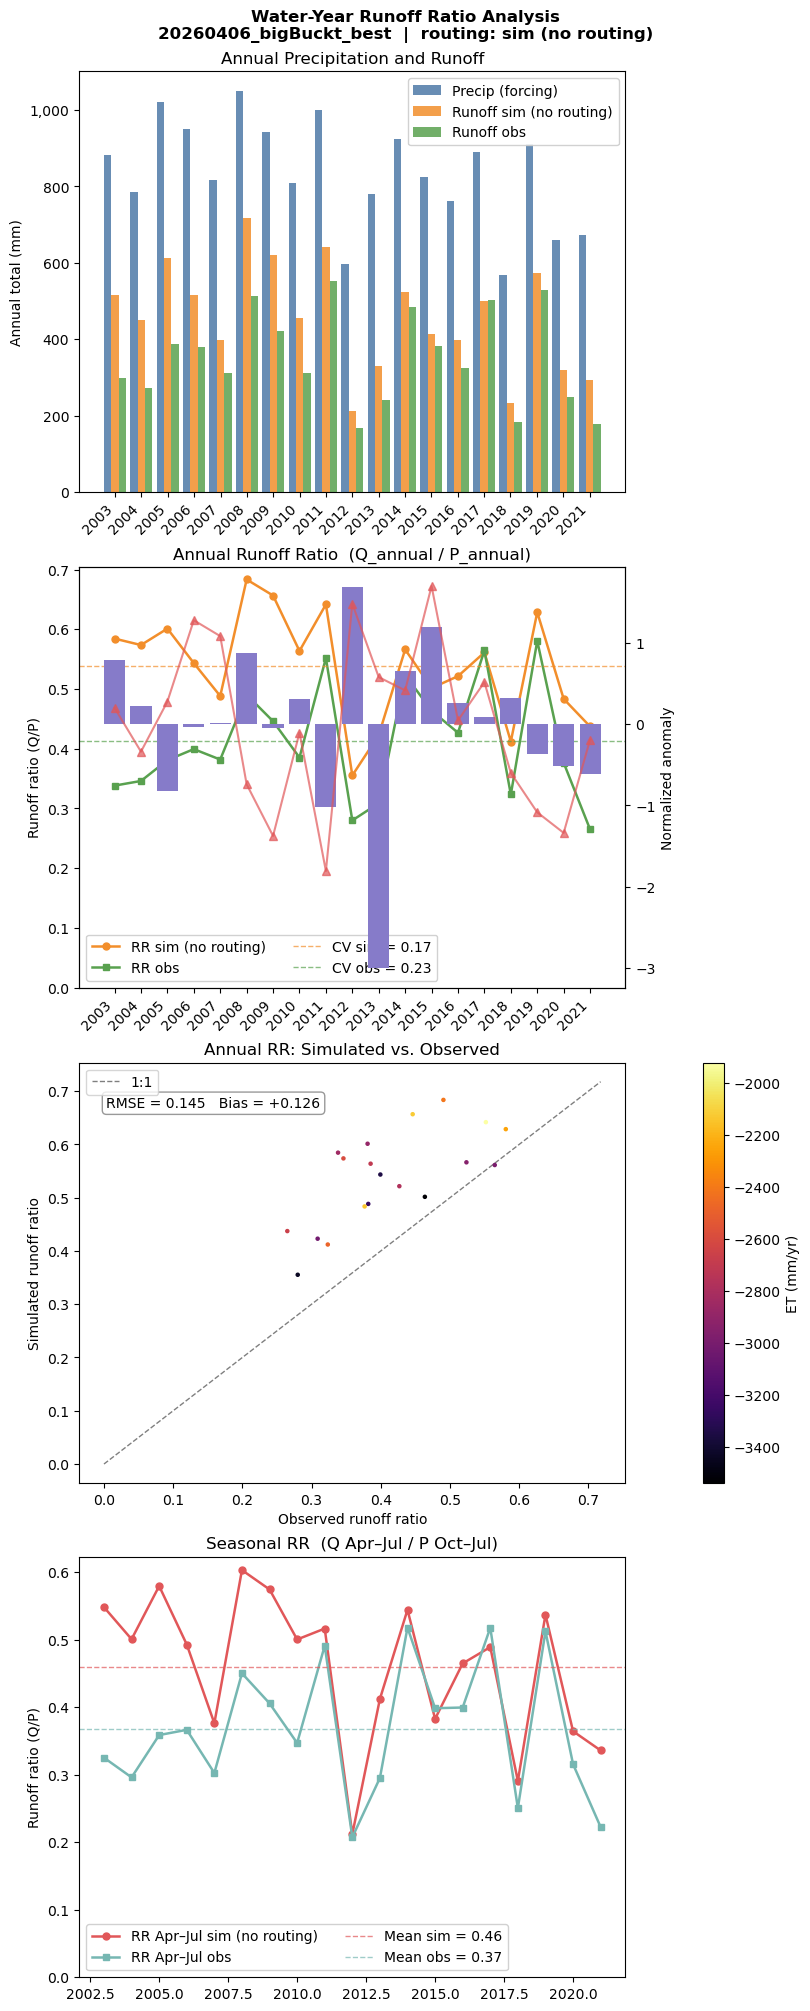

In [137]:
wys  = wy_totals.index.values
x    = np.arange(len(wys))
w    = 0.28

n_panels = 4 if CALC_SEASONAL_RR else 3
fig, axes = plt.subplots(n_panels, 1, figsize=(8, 5 * n_panels), constrained_layout=True)
fig.suptitle(
    f"Water-Year Runoff Ratio Analysis\n{SIM_DIR.name}  |  routing: {_routing_label}",
    fontsize=12, fontweight="bold"
)

# ── Panel 1: Annual water balance bars ────────────────────────────────────────
ax = axes[0]
ax.bar(x - w, wy_totals["ppt"],   width=w, label="Precip (forcing)",         color="#4E79A7", alpha=0.85)
ax.bar(x,     wy_totals["q_sim"], width=w, label=f"Runoff {_routing_label}",  color="#F28E2B", alpha=0.85)
ax.bar(x + w, wy_totals["q_obs"], width=w, label="Runoff obs",                color="#59A14F", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(wys, rotation=45, ha="right")
ax.set_ylabel("Annual total (mm)")
ax.set_title("Annual Precipitation and Runoff")
ax.legend(framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

# ── Panel 2: Annual runoff ratio time series ──────────────────────────────────
ax = axes[1]
ax.plot(wys, wy_totals["rr_sim"], "o-", color="#F28E2B", linewidth=1.8, markersize=5,
        label=f"RR {_routing_label}")
ax.plot(wys, wy_totals["rr_obs"], "s-", color="#59A14F", linewidth=1.8, markersize=5, label="RR obs")
ax.axhline(wy_totals["rr_sim"].mean(), color="#F28E2B", linestyle="--", linewidth=1, alpha=0.7,
           label=f"CV sim = {wy_totals['rr_sim'].std()/wy_totals['rr_sim'].mean():.2f}")
ax.axhline(wy_totals["rr_obs"].mean(), color="#59A14F", linestyle="--", linewidth=1, alpha=0.7,
           label=f"CV obs = {wy_totals['rr_obs'].std()/wy_totals['rr_obs'].mean():.2f}")

ax2 = ax.twinx()
ax2.bar(wys, wy_totals["storage_anomaly"],color="#867BC9", linewidth=1.5, label="Δ storage (mm/yr)")
ax2.plot(wys, -wy_totals["et_anomaly"], "^-", color="#E15759", linewidth=1.5, label="ET sim (mm/yr)", alpha=0.7)
ax2.set_ylabel("Normalized anomaly")
# ax2.set_ylim(-60,60)
ax.set_xticks(wys); ax.set_xticklabels(wys, rotation=45, ha="right")
ax.set_ylabel("Runoff ratio (Q/P)")
ax.set_title("Annual Runoff Ratio  (Q_annual / P_annual)")
ax.set_ylim(0, None)
ax.legend(framealpha=0.9, ncol=2)

# ── Panel 3: Annual sim vs obs scatter ───────────────────────────────────────
ax = axes[2]
valid = wy_totals.dropna(subset=["rr_obs"])
sc = ax.scatter(valid["rr_obs"], valid["rr_sim"], c=valid['et_sim']*10, cmap="inferno", s=5, zorder=3)
plt.colorbar(sc, ax=ax, label="ET (mm/yr)")
lim = max(valid[["rr_obs", "rr_sim"]].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.5, label="1:1")
ax.set_xlabel("Observed runoff ratio")
ax.set_ylabel("Simulated runoff ratio")
ax.set_title("Annual RR: Simulated vs. Observed")
ax.legend()
rmse = np.sqrt(((valid["rr_sim"] - valid["rr_obs"])**2).mean())
bias = (valid["rr_sim"] - valid["rr_obs"]).mean()
ax.text(0.05, 0.92, f"RMSE = {rmse:.3f}   Bias = {bias:+.3f}",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

# ── Panel 4 (optional): Apr–Jul RR time series ───────────────────────────────
if CALC_SEASONAL_RR:
    ax = axes[3]
    ax.plot(wys, wy_totals["rr_sim_amjj"], "o-", color="#E15759", linewidth=1.8, markersize=5,
            label=f"RR Apr–Jul {_routing_label}")
    ax.plot(wys, wy_totals["rr_obs_amjj"], "s-", color="#76B7B2", linewidth=1.8, markersize=5,
            label="RR Apr–Jul obs")
    ax.axhline(wy_totals["rr_sim_amjj"].mean(), color="#E15759", linestyle="--", linewidth=1, alpha=0.7,
               label=f"Mean sim = {wy_totals['rr_sim_amjj'].mean():.2f}")
    ax.axhline(wy_totals["rr_obs_amjj"].dropna().mean(), color="#76B7B2", linestyle="--",
               linewidth=1, alpha=0.7,
               label=f"Mean obs = {wy_totals['rr_obs_amjj'].dropna().mean():.2f}")
#     ax.set_xticks(x); ax.set_xticklabels(wys, rotation=45, ha="right")
    ax.set_ylabel("Runoff ratio (Q/P)")
    ax.set_title("Seasonal RR  (Q Apr–Jul / P Oct–Jul)")
    ax.set_ylim(0, None)
    ax.legend(framealpha=0.9, ncol=2)

# _fname = f"runoff_ratio_analysis{'_routed' if APPLY_LINEAR_RESERVOIR else ''}{'_seasonal' if CALC_SEASONAL_RR else ''}.png"
# plt.savefig(SIM_DIR / _fname, dpi=150, bbox_inches="tight")
plt.show()
# print(f"Figure saved to {SIM_DIR / _fname}")

## Runoff Ratio vs. Normalized ET and Storage

Two-axis per-water-year plot:
- **Top:** simulated and observed annual runoff ratios
- **Bottom:** water-year mean ET and total storage (soil liquid + ice + SWE), each normalized 0–1 across the record, on a shared dual y-axis

Storage = `scalarTotalSoilLiq + scalarTotalSoilIce + scalarSWE` [kg m⁻²]  
ET = `scalarTotalET` [kg m⁻² s⁻¹ → mm/yr]

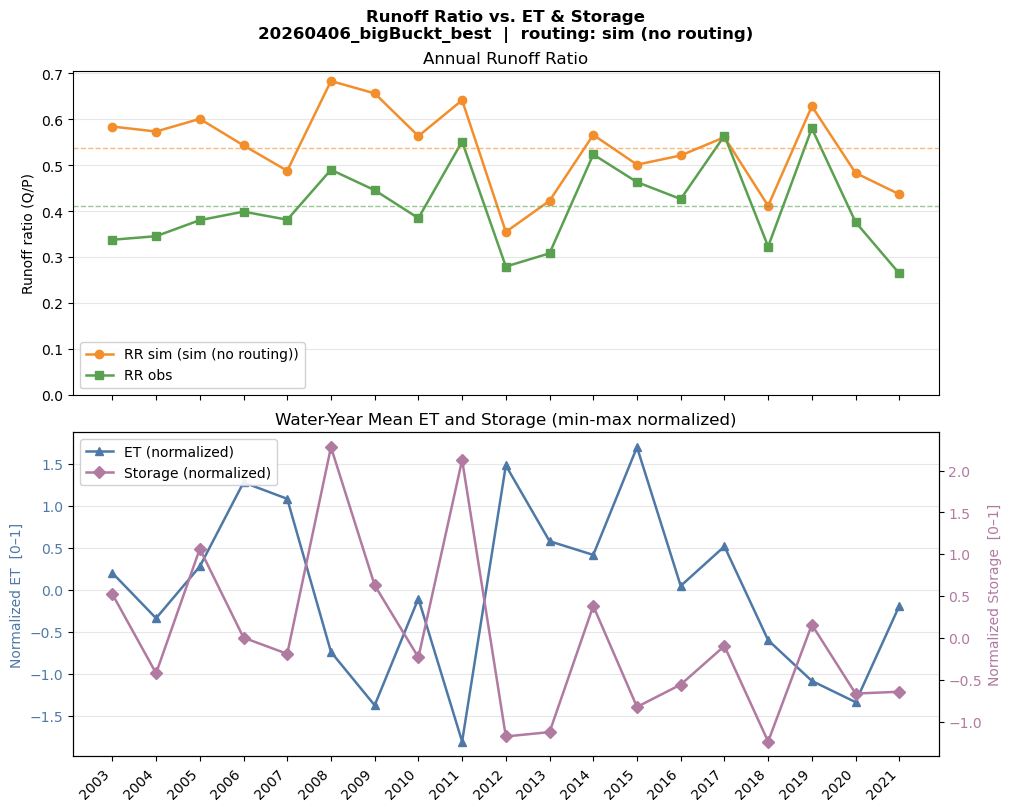

In [ ]:
def _norm(s: pd.Series) -> pd.Series:
    """Min-max normalise a series to [0, 1]."""
    mean, std = s.mean(), s.std()
    return (s - mean) / std if std != 0 else s * 0.0


# ── Water-year ET (mm/yr): scalarTotalET [kg m-2 s-1] × 3600 s/hr × sum daily hrs ──
et_mm_hr = -ds["scalarTotalET"].isel(hru=0).to_series() * 3600.0
et_mm_day = et_mm_hr.resample("1D").sum()
et_daily = et_mm_day.copy()
et_daily_df = et_daily.to_frame("et")
et_daily_df["wy"] = water_year(et_daily_df.index)
wy_et = et_daily_df.groupby("wy")["et"].sum()

# ── Water-year mean total storage [kg m-2] ────────────────────────────────────
# Sum of soil liquid + soil ice + SWE, averaged over the water year (state var)
stor_series = (
    ds["scalarTotalSoilLiq"].isel(hru=0).to_series()
    + ds["scalarTotalSoilIce"].isel(hru=0).to_series()
    + ds["scalarSWE"].isel(hru=0).to_series()
)
stor_daily = stor_series.resample("1D").mean()
stor_daily_df = stor_daily.to_frame("storage")
stor_daily_df["wy"] = water_year(stor_daily_df.index)
wy_stor = stor_daily_df.groupby("wy")["storage"].mean()

# Align to the same water years as wy_totals
wy_et   = wy_et.reindex(wy_totals.index)
wy_stor = wy_stor.reindex(wy_totals.index)

et_norm   = _norm(wy_et)
stor_norm = _norm(wy_stor)

# ── Plot ──────────────────────────────────────────────────────────────────────
wys = wy_totals.index.values
x   = np.arange(len(wys))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True,
                                      sharex=True)
fig.suptitle(
    f"Runoff Ratio vs. ET & Storage\n{SIM_DIR.name}  |  routing: {_routing_label}",
    fontsize=12, fontweight="bold"
)

# ── Top: runoff ratios ────────────────────────────────────────────────────────
ax_top.plot(x, wy_totals["rr_sim"], "o-", color="#F28E2B", linewidth=1.8, markersize=6,
            label=f"RR sim ({_routing_label})")
ax_top.plot(x, wy_totals["rr_obs"], "s-", color="#59A14F", linewidth=1.8, markersize=6,
            label="RR obs")
ax_top.axhline(wy_totals["rr_sim"].mean(), color="#F28E2B", linestyle="--", linewidth=1, alpha=0.6)
ax_top.axhline(wy_totals["rr_obs"].mean(), color="#59A14F", linestyle="--", linewidth=1, alpha=0.6)
ax_top.set_ylabel("Runoff ratio (Q/P)")
ax_top.set_title("Annual Runoff Ratio")
ax_top.set_ylim(0, None)
ax_top.legend(framealpha=0.9)
ax_top.grid(axis="y", alpha=0.3)

# ── Bottom: normalized ET (left axis) and storage (right axis) ────────────────
color_et   = "#4E79A7"
color_stor = "#B07AA1"

ax_et = ax_bot
ax_st = ax_bot.twinx()

l1, = ax_et.plot(x, et_norm,   "^-", color=color_et,   linewidth=1.8, markersize=6,
                 label="ET (standardized)")
l2, = ax_st.plot(x, stor_norm, "D-", color=color_stor, linewidth=1.8, markersize=6,
                 label="Storage (standardized)")

ax_et.set_ylabel("Standardized ET  [0–1]", color=color_et)
ax_st.set_ylabel("Standardized Storage  [0–1]", color=color_stor)
ax_et.tick_params(axis="y", labelcolor=color_et)
ax_st.tick_params(axis="y", labelcolor=color_stor)
# ax_et.set_ylim(-0.05, 1.15)
# ax_st.set_ylim(-0.05, 1.15)

ax_et.set_xticks(x)
ax_et.set_xticklabels(wys, rotation=45, ha="right")
ax_et.set_title("Water-Year Mean ET and Storage (min-max normalized)")
ax_et.grid(axis="y", alpha=0.3)

lines  = [l1, l2]
labels = [l.get_label() for l in lines]
ax_et.legend(lines, labels, framealpha=0.9, loc="upper left")

# _fname2 = f"rr_et_storage{'_routed' if APPLY_LINEAR_RESERVOIR else ''}.png"
# plt.savefig(SIM_DIR / _fname2, dpi=150, bbox_inches="tight")
plt.show()
# print(f"Figure saved to {SIM_DIR / _fname2}")